# Classification. Linear models and KNN

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import plot_confusion_matrix, accuracy_score
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder

In [116]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score

## Part 2: Porto Seguro’s Safe Driver Prediction

Let's build a model that predicts the probability that a driver will initiate an auto insurance claim in the next year.
Read the detailed description and download the dataset https://www.kaggle.com/c/porto-seguro-safe-driver-prediction/data. Put the data into *./data/porto/*.

In [3]:
PATH = "./data/"

In [4]:
insurance_data = pd.read_csv(os.path.join(PATH, 'porto', 'train.csv')).set_index('id')

In [5]:
insurance_data.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
id,,,,,,,,,,,,,,,,,,,,,
7,0,2,2,5,1,0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
9,0,1,1,7,0,0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
13,0,5,4,9,1,0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
16,0,0,1,2,0,0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
17,0,0,2,0,1,0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0


Let's skip EDA for now. We'll use SGDClassifier and build a simple baseline: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html.
Note that loss='log' gives logistic regression.

In [6]:
y = insurance_data['target']
X = insurance_data.drop(columns=['target'])

In [7]:
numeric_features = [column for column in X if not (column.endswith("cat") or column.endswith("bin"))]
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = [column for column in X if (column.endswith("cat") or column.endswith("bin"))]
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', SGDClassifier(loss='log', alpha=0.001, n_jobs=-1, random_state=14))])

In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [9]:
clf = pipeline.fit(X_train, y_train)

We'll calculate the model accuracy:

In [10]:
accuracy_score(y_true=y_valid, y_pred=clf.predict(X_valid))

0.9631224658945812

Wow! Our model gets ~0.963 accuracy! But is it really good?...

Let's plot the confusion matrix and analyze the errors.

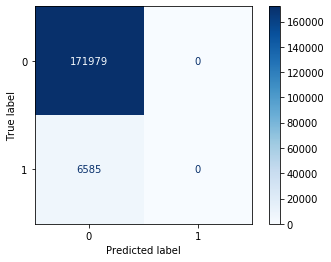

In [11]:
disp = plot_confusion_matrix(clf, X_valid, y_valid,
                             cmap=plt.cm.Blues,
                             normalize=None)

Well, it turns out that our model is completely useless. Let's calculate some basic statistics:

In [12]:
insurance_data.describe()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,0.185304,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,0.388544,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


As you see, there are less than 4% of positive examples, so we have to deal with a highly imbalanced dataset.

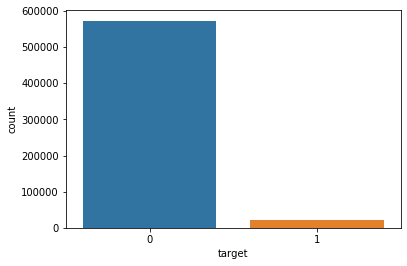

In [13]:
sns.countplot(x='target', data=insurance_data)
plt.show()

Accuracy is not informative here and the Normalized Gini Coefficient will be used instead: https://www.kaggle.com/c/porto-seguro-safe-driver-prediction/overview/evaluation.

In [14]:
# Code for calculating Normalized gini coefficient
# https://www.kaggle.com/c/ClaimPredictionChallenge/discussion/703
def gini(actual, pred, cmpcol = 0, sortcol = 1):  
    assert(len(actual) == len(pred))  
    epsilon = 1e-7
    values = np.asarray(np.c_[actual, pred, np.arange(len(actual))], dtype=np.float)  
    values = values[np.lexsort((values[:, 2], -1 * values[:, 1]))]  
    total = values[:, 0].sum() 
    gini_sum = (values[:, 0].cumsum().sum() + epsilon) / (total + epsilon)  
  
    gini_sum -= (len(actual) + 1) / 2  
    return gini_sum / len(actual)  
  
def gini_normalized(a, p):  
    '''Function to calculate the normalized gini coefficient'''
    return gini(a, p) / gini(a, a)

**(1.5 points)** Prove that the **Normalized Gini Coefficient** is equivalent to **2 x AUC - 1** :

Firstly, it is important to understand what does the Normalized Gini Coefficient stand for.
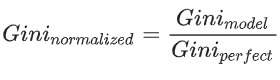
So it is the relation of a trained model coefficient to an ideal model coefficient. 
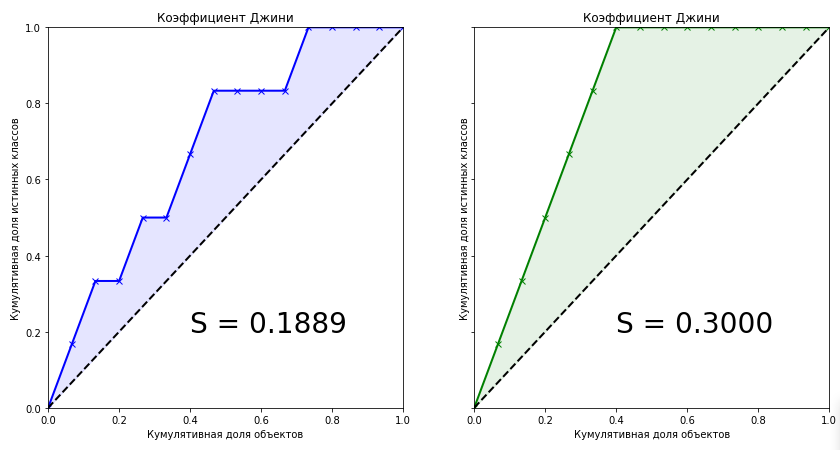


In other words, it shows how well our model can capture a true distribution of the data.
The area of 2 figures is shaped by the Lift Curve (cumulative share of objects) and the line of absolute equality (dashed line).

But it is rather hard to see the relation between the Normalized Gini Coefficient and AUC. It can not be derived intuitively from graphs below. 
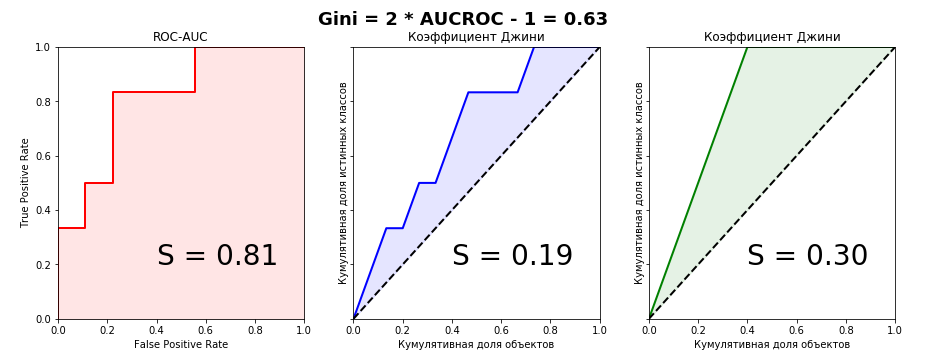

So here are some notions:
- n — total number of objects
- n0 — number of 0s 
- n1 — number of 1s
- TP — True Positive
- FP — False Positive 
- TPR — True Positive Rate
- FPR — False Positive Rate
- i,j — current index of element

It is known that the numerical value of AUC ROC is equal to the Wilcoxon-Mann-Whitney statistic
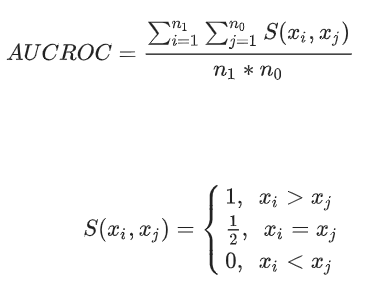
where Xi is the response of the algorithm on the i-th object from the distribution "1", 
Xj is the response of the algorithm on the j-th object from the distribution "0"

if you randomly extract a pair of objects, where the first object will be from the distribution "1", and the second from the distribution "0", then the probability that the first object will have a predicted value is greater than or equal to the predicted value of the second object is equal to the AUC ROC value.

Let the model predict k possible values from the set S={s1, s2,.., sk}, where s1<...<sk and S is some kind of probability distribution, the elements of which take values on the interval [0, 1].
Let Sn1 the set of values that objects n1 take and Sn1 is subset of S. Let Sn0 the set of values that objects n0 take and Sn0 is subset of S. It is obvious that the sets Sn1 and Sn0 can intersect.

Let's denote 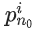 as the probability that the object n0 will take a value si, and   as the probability that the object n1 will take a value si. Then 
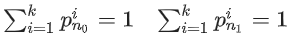
Having an a priori probability π for each object in the sample, we can write a formula that determines the probability that the object will take a value si:
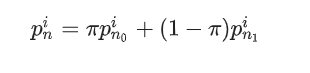

Let's set three distribution functions:
- for objects of class "1"
- for objects of class "0"
- for all objects of the selection
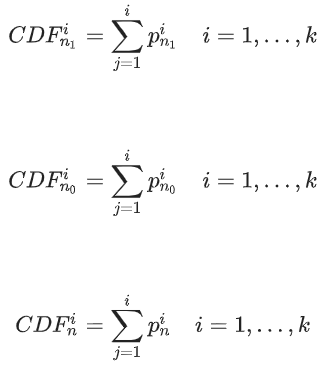

Let's write down Wilcoxon's formula in probabilistic form and transform it:
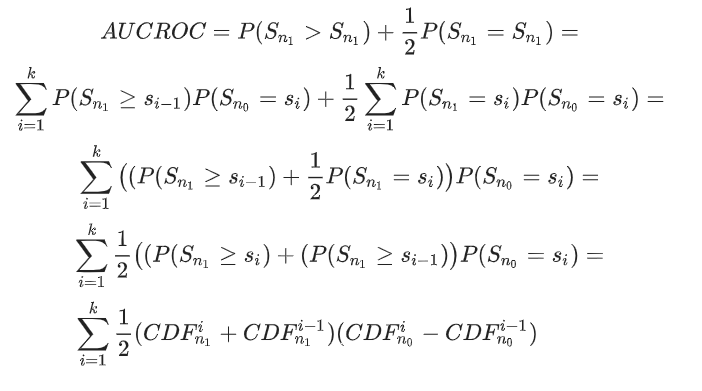

We can write a similar formula for the area under the Lift Curve (remember that it consists of the sum of two areas, one of which is always 0.5):
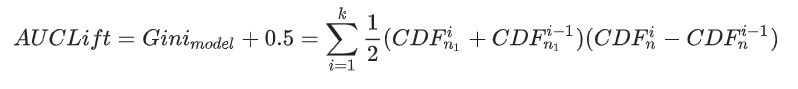
Now let's transform it:
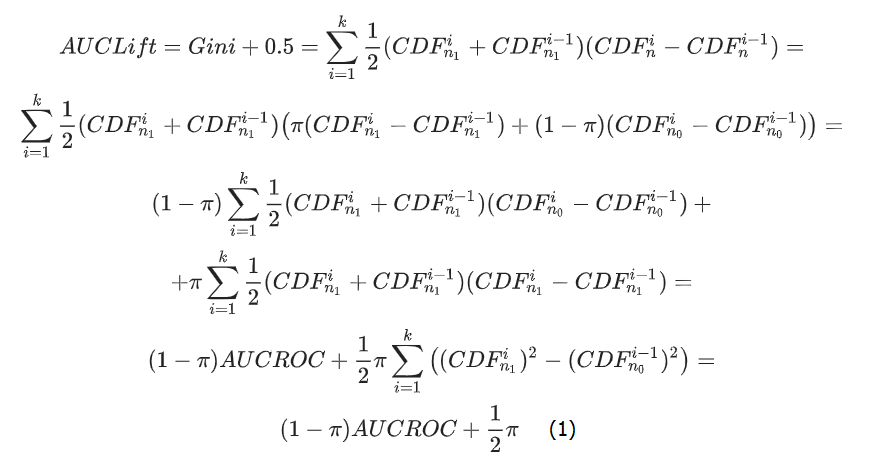

For an ideal model, the formula is simple:
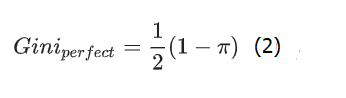
Therefore, from (1) and (2), we get:

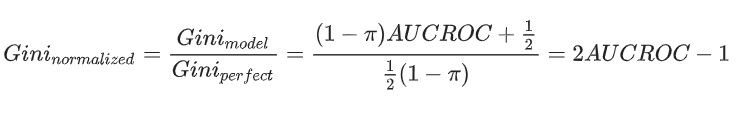

**(0.5 points)** By the way, what other metrics could you suggest for this problem?

It is useful to use such insighful performance measures:

- Confusion Matrix: A breakdown of predictions into a table showing correct predictions (the diagonal) and the types of incorrect predictions made (what classes incorrect predictions were assigned).
- Precision: A measure of a classifiers exactness.
- Recall: A measure of a classifiers completeness
- F1 Score (or F-score): A weighted average of precision and recall.
- Kappa (or Cohen’s kappa): Classification accuracy normalized by the imbalance of the classes in the data.
- ROC Curves: Like precision and recall, accuracy is divided into sensitivity and specificity and models can be chosen based on the balance thresholds of these values.

Let's calculate the Normalized Gini Coefficient:

In [15]:
y_pred = clf.predict_proba(X_valid)[:, 1]

In [16]:
gini_normalized(y_valid, y_pred)

C:\Users\dasha\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


0.2558723581569817

**(0.5 points + Y bonus points)** Try different approaches: oversampling / undersampling, careful feature analysis and feature engineering, etc., to get a reasonable pipeline and improve the model quality. Use cross-validation for model evaluation.

Select the best model, load the test set and make the predictions. Submit them to kaggle.
Y bonus points will be calculated as $\frac{round(200 * \max(score - 0.253, 0))}{2}$, where *score* is your kaggle leaderboard score.

Note: do not use any classification models which have not been covered in the lessons yet.

In [92]:
y = insurance_data['target']
X = insurance_data.drop(columns=['target'])

>Let's try something simple without any complex feature preprocessing:

In [67]:
#simple log reg with low score
clf = LogisticRegression(solver='lbfgs', penalty='l2')
pipe_scaled = make_pipeline(StandardScaler(), clf)
pipe_scaled.fit(X_train, y_train)
y_pred = pipe_scaled.predict_proba(X_valid)[:, 1]
gini_normalized(y_valid, y_pred)

C:\Users\dasha\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


0.245798865711958

>Hm... The result doesn't look very high. The dataset is very imbalanced, what if to try some under-sampling?

In [38]:
from imblearn.under_sampling import InstanceHardnessThreshold
iht = InstanceHardnessThreshold(random_state=0,
                                estimator=LogisticRegression(
                                    solver='lbfgs', multi_class='auto', max_iter=2000))
X_resampled, y_resampled = iht.fit_resample(X, y)

In [46]:
numeric_features = [column for column in X if not (column.endswith("cat") or column.endswith("bin"))]
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = [column for column in X if (column.endswith("cat") or column.endswith("bin"))]
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer( 
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(solver='liblinear', penalty='l1', max_iter=2000))])

In [39]:
X_train, X_valid, y_train, y_valid = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

In [40]:
logreg = LogisticRegression(solver='lbfgs', multi_class='auto', max_iter=2000)
clf = logreg.fit(X_train, y_train)

In [41]:
y_pred = clf.predict_proba(X_valid)[:, 1]
gini_normalized(y_valid, y_pred)

C:\Users\dasha\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


0.9860820043004894

In [47]:
clf = pipeline.fit(X_train, y_train)

In [48]:
y_pred = clf.predict_proba(X_valid)[:, 1]
gini_normalized(y_valid, y_pred)

C:\Users\dasha\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


0.9866955037530378

>Looks great! But it gave only 0.24884 and 0.24824 on Kaggle :( Probably, it's because the model learnt patterns in the dataset balanced more than it was useful for the test prediction.

In [59]:
numeric_features = [column for column in X if not (column.endswith("cat") or column.endswith("bin"))]
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = [column for column in X if (column.endswith("cat") or column.endswith("bin"))]
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(solver='liblinear', random_state=2020, penalty='l1', max_iter=2000))])

In [51]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42)

In [60]:
clf = pipeline.fit(X_train, y_train)

In [61]:
y_pred = clf.predict_proba(X_valid)[:, 1]
gini_normalized(y_valid, y_pred)

C:\Users\dasha\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


0.2610730867180541

>Here is my best result. I changed the model type to LogisticRegression(solver='liblinear', penalty='l1', max_iter=2000) and got the private score = 0.26481 (random_state=2020)

> However, I had one more experiment. I tried to apply more feature preprocessing (like PCA, but it doesn't work with sparse data, so I used TruncatedSVD)

In [70]:
from sklearn.decomposition import TruncatedSVD

In [101]:
numeric_features = [column for column in X if not (column.endswith("cat") or column.endswith("bin"))]
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

categorical_features = [column for column in X if (column.endswith("cat") or column.endswith("bin"))]
categorical_transformer = Pipeline(steps=[('encoder', OneHotEncoder(handle_unknown='ignore')), 
                                         ('truncatedSVD', TruncatedSVD(n_components=80, algorithm='arpack', random_state=2020))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)])

pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                           ('classifier', LogisticRegression(solver='liblinear', random_state=2020, penalty='l1', max_iter=2000))])

In [102]:
clf1 = pipeline.fit(X_train, y_train)

In [103]:
y_pred = clf1.predict_proba(X_valid)[:, 1]
gini_normalized(y_valid, y_pred)

C:\Users\dasha\Anaconda3\lib\site-packages\ipykernel_launcher.py:6: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


0.25777647720055846

> - When I set n_components=30 I got 0.253 and 0.25555 on Kaggle
- n_components=40 I got 0.2564 and 0.25835 on Kaggle
- n_components=50 I got 0.2585 and 0.26022 on Kaggle
- n_components=80 I got 0.2578 and 0.26205 on Kaggle

>Maybe it is possible to increase the number of components and get a higher score. But you need to use a relatively high number (above 100) which would increase computational time dramatically.

>Now let's load the test data, then predict probalities (using our best model with gini normalized = 0.26107) and know the final private score on Kaggle.

In [46]:
insurance_test = pd.read_csv(os.path.join(PATH, 'porto', 'test.csv'))

In [98]:
X_val = insurance_test.drop(columns=['id'])

In [104]:
target = clf.predict_proba(X_val)[:, 1]

In [105]:
output = pd.DataFrame({'id': insurance_test.id, 'target': target})
output.to_csv('my_porto_submission.csv', index=False)

In [57]:
def points_porto(score):
    points = (round(200*max(score-0.253,0)))/2
    return points

In [65]:
points_porto(0.26481)

1.0

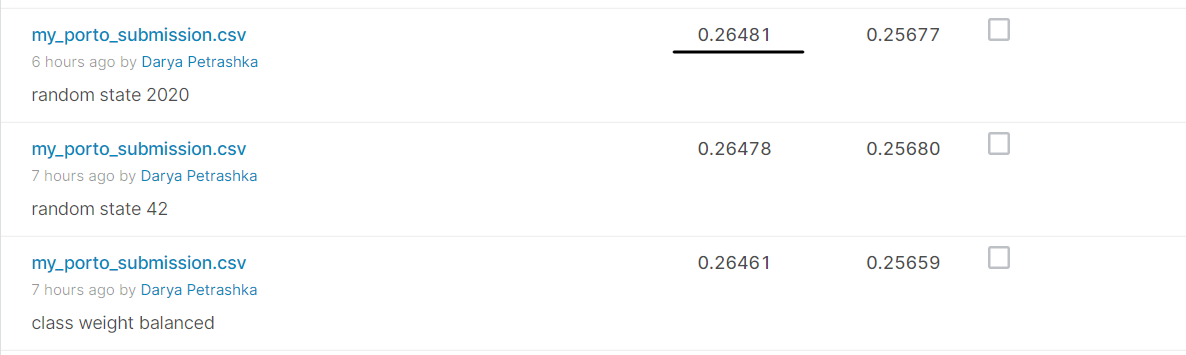